In [1]:
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

import scipy.linalg
from sklearn.decomposition import FastICA



# ======================== НАСТРОЙКИ ========================
np.random.seed(42)
N_CHANNELS = 10
N_TIMEPOINTS = 500
TIME_AXIS = np.arange(N_TIMEPOINTS)
AMP_1, FREQ_1 = 2.0, 0.05
AMP_2, FREQ_2 = 1.0, 0.10
PLOT_LIMIT = 100
VERT_OFFSET = 2.5

# Истинные паттерны (не менять)
spatial_1 = np.sin(np.linspace(0, 2*np.pi, N_CHANNELS))
spatial_2 = np.cos(np.linspace(0, 2*np.pi, N_CHANNELS))
temporal_1 = AMP_1 * np.sin(2*np.pi*FREQ_1*TIME_AXIS)
temporal_2 = AMP_2 * np.sin(2*np.pi*FREQ_2*TIME_AXIS)

def generate_data(noise_level):
    clean = np.outer(spatial_1, temporal_1) + np.outer(spatial_2, temporal_2)
    noise = np.random.randn(N_CHANNELS, N_TIMEPOINTS) * noise_level
    return clean + noise, clean, noise

def normalize_component(weights, temporal_pc, ref_signal=None, target_amp=None):
    scale = np.max(np.abs(weights))
    w_norm, t_norm = weights/scale, temporal_pc*scale
    if ref_signal is not None:
        if np.corrcoef(t_norm, ref_signal)[0,1] < 0:
            w_norm, t_norm = -w_norm, -t_norm
    if target_amp is not None and np.max(np.abs(t_norm)) > 0:
        t_norm = t_norm / np.max(np.abs(t_norm)) * target_amp
    return w_norm, t_norm

def plot_results(noisy_data, components, spatial_weights, titles, plot_limit=100):
    n_chan = noisy_data.shape[0]
    fig, ax = plt.subplots(figsize=(8,3))
    for ch in range(min(5, n_chan)):
        ax.plot(TIME_AXIS[:plot_limit], noisy_data[ch,:plot_limit] + ch*VERT_OFFSET, lw=0.8, alpha=0.7)
    ax.set_xlabel('Время'); ax.set_ylabel('Канал'); ax.set_title('Исходные данные'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    
    fig, ax = plt.subplots(figsize=(6,4))
    for w, lbl in zip(spatial_weights[:3], titles[:3]):
        ax.plot(np.arange(len(w)), w, marker='o', ms=3, label=lbl)
    ax.set_xlabel('Канал'); ax.set_ylabel('Вес'); ax.set_title('Пространственные паттерны'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    
    fig, ax = plt.subplots(figsize=(8,4))
    for t, lbl in zip(components[:3], titles[:3]):
        ax.plot(TIME_AXIS[:plot_limit], t[:plot_limit], label=lbl, lw=1.5)
    ax.plot(TIME_AXIS[:plot_limit], temporal_1[:plot_limit], 'k--', label='Источник 1', alpha=0.7)
    ax.plot(TIME_AXIS[:plot_limit], temporal_2[:plot_limit], 'r--', label='Источник 2', alpha=0.7)
    ax.set_xlabel('Время'); ax.set_ylabel('Амплитуда'); ax.set_title('Временные компоненты'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


# ЗАДАНИЕ 1 - PCA


=== ЗАДАНИЕ 1: PCA ===


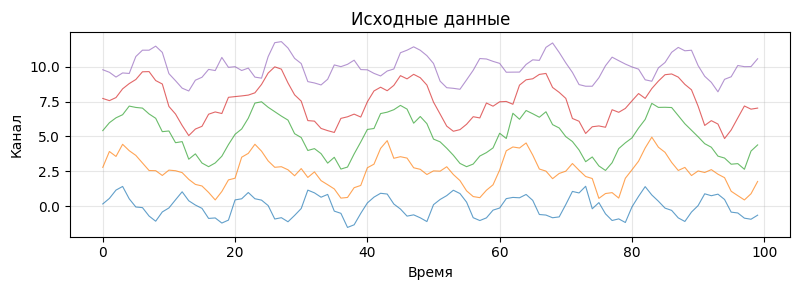

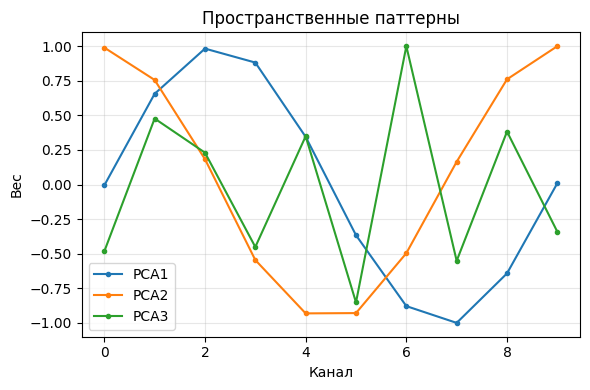

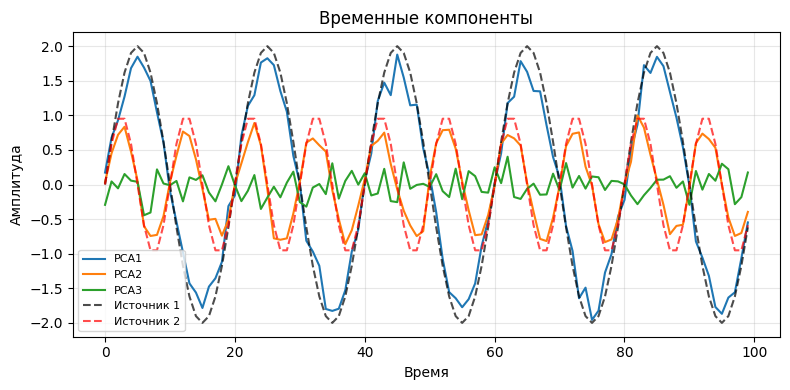

PCA: corr1 = 0.9946, corr2 = 0.9862


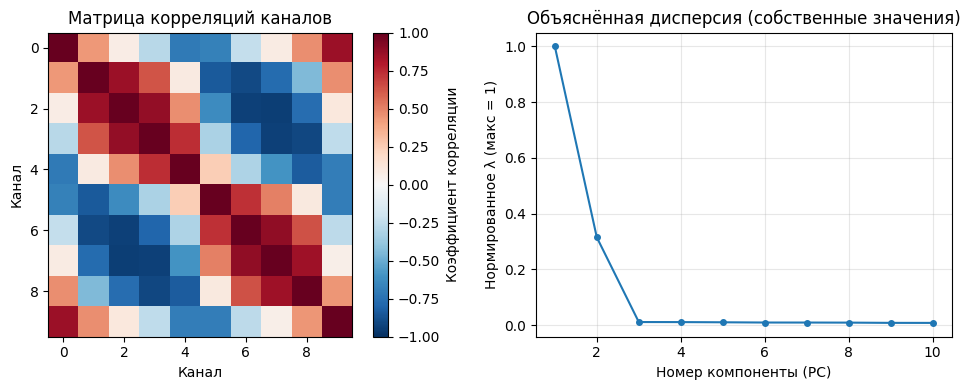

In [2]:
print("\n=== ЗАДАНИЕ 1: PCA ===")
NOISE_1 = 0.3
noisy_1, clean_1, noise_1 = generate_data(NOISE_1)

# <-- Центрирование: вычесть среднее по времени (ось=1) для каждого канала
data_centered_1 = noisy_1 - noisy_1.mean(axis=1, keepdims=True)

# <-- Ковариационная матрица (каналы × каналы)
cov_matrix_1 = np.cov(data_centered_1)

# <-- Собственные значения и векторы (np.linalg.eigh)
eigenvalues_1, eigenvectors_1 = np.linalg.eigh(cov_matrix_1)

# <-- Отсортируйте по убыванию eigenvalues и переставьте eigenvectors
sorted_idx_1 = np.argsort(eigenvalues_1)[::-1]
eigenvalues_1 = eigenvalues_1[sorted_idx_1]
eigenvectors_1 = eigenvectors_1[:, sorted_idx_1]

# <-- Проекция на главные компоненты (eigenvectors.T @ data_centered)
principal_components_1 = eigenvectors_1.T @ data_centered_1

# Визуализация
w1,t1 = normalize_component(eigenvectors_1[:,0], principal_components_1[0], temporal_1, AMP_1)
w2,t2 = normalize_component(eigenvectors_1[:,1], principal_components_1[1], temporal_2, AMP_2)
w3,t3 = normalize_component(eigenvectors_1[:,2], principal_components_1[2])
plot_results(noisy_1, [t1,t2,t3], [w1,w2,w3], ['PCA1','PCA2','PCA3'])

# <-- Вычислите корреляции t1 с temporal_1 и t2 с temporal_2
corr1_pca = np.corrcoef(t1, temporal_1)[0, 1]
corr2_pca = np.corrcoef(t2, temporal_2)[0, 1]
print(f"PCA: corr1 = {corr1_pca:.4f}, corr2 = {corr2_pca:.4f}")


# --- ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ ДЛЯ PCA ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. Матрица корреляций
im = axes[0].imshow(np.corrcoef(noisy_1), cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Матрица корреляций каналов')
axes[0].set_xlabel('Канал'); axes[0].set_ylabel('Канал')
plt.colorbar(im, ax=axes[0], label='Коэффициент корреляции')

# 2. Объясненная дисперсия
axes[1].plot(range(1, len(eigenvalues_1) + 1), eigenvalues_1 / np.max(eigenvalues_1), marker='o', ms=4)
axes[1].set_title('Объяснённая дисперсия (собственные значения)')
axes[1].set_xlabel('Номер компоненты (PC)')
axes[1].set_ylabel('Нормированное λ (макс = 1)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ЗАДАНИЕ 2 - GED


=== ЗАДАНИЕ 2: GED ===


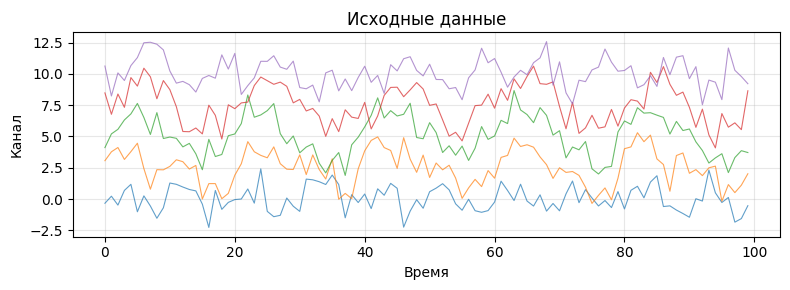

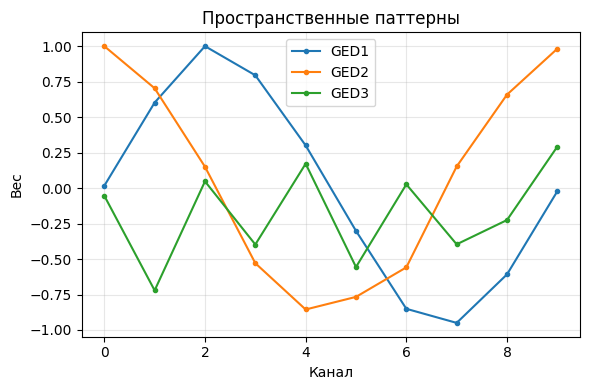

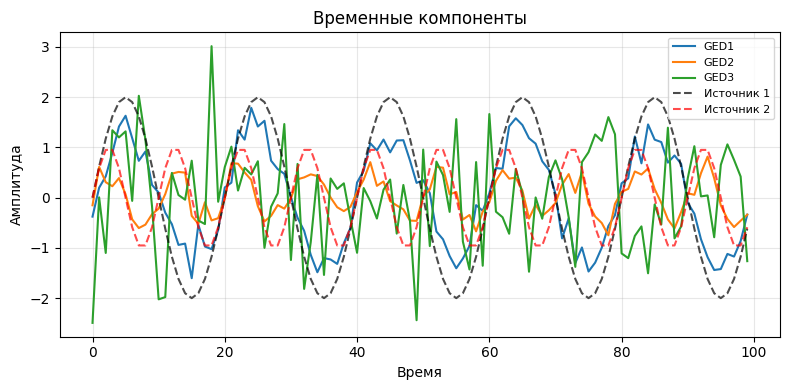

GED: corr1 = 0.9673, corr2 = 0.9061


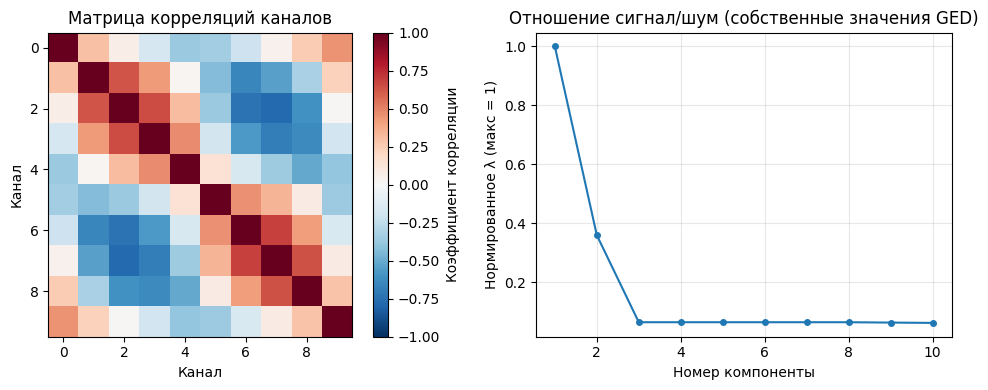

In [3]:
# ======================== ЗАДАНИЕ 2: GED ========================
print("\n=== ЗАДАНИЕ 2: GED ===")
NOISE_2 = 0.8
noisy_2, clean_2, noise_2 = generate_data(NOISE_2)

data_c_2 = noisy_2 - noisy_2.mean(axis=1, keepdims=True)
noise_c_2 = noise_2 - noise_2.mean(axis=1, keepdims=True)

# <-- Ковариация сигнал+шум и ковариация шума
cov_sig_2 = np.cov(data_c_2)
cov_noise_2 = np.cov(noise_c_2)

# <-- Регуляризация шумовой ковариации: cov_noise_reg = cov_noise + 1e-8 * trace/n_chan * I
reg = 1e-8 * np.trace(cov_noise_2) / N_CHANNELS
cov_noise_reg_2 = cov_noise_2 + reg * np.eye(N_CHANNELS)

# <-- Обобщённое собственное разложение: scipy.linalg.eigh(cov_sig, cov_noise_reg)
evals_2, evecs_2 = scipy.linalg.eigh(cov_sig_2, cov_noise_reg_2)

# <-- Отсортируйте evals по убыванию, переставьте evecs и вычислите временные компоненты comp_ts = evecs.T @ data_c_2
sorted_idx_2 = np.argsort(evals_2)[::-1]
evals_2 = evals_2[sorted_idx_2]
evecs_2 = evecs_2[:, sorted_idx_2]

comp_ts_2 = evecs_2.T @ data_c_2

# Форвард-модель: a = (C_sig @ w) / (w.T @ C_noise @ w)
def compute_forward(w, C_sig, C_noise):
    denom = w.T @ C_noise @ w
    if np.abs(denom) < 1e-12:
        return np.zeros_like(w)
    return (C_sig @ w) / denom

C_sig_diff_2 = cov_sig_2 - cov_noise_2
f1 = compute_forward(evecs_2[:,0], C_sig_diff_2, cov_noise_reg_2)
f2 = compute_forward(evecs_2[:,1], C_sig_diff_2, cov_noise_reg_2)

w1g,t1g = normalize_component(f1, comp_ts_2[0], temporal_1, AMP_1)
w2g,t2g = normalize_component(f2, comp_ts_2[1], temporal_2, AMP_2)
plot_results(noisy_2, [t1g,t2g,comp_ts_2[2]], [w1g,w2g,evecs_2[:,2]], ['GED1','GED2','GED3'])

# <-- Корреляции
corr1_ged = np.corrcoef(t1g, temporal_1)[0, 1]
corr2_ged = np.corrcoef(t2g, temporal_2)[0, 1]
print(f"GED: corr1 = {corr1_ged:.4f}, corr2 = {corr2_ged:.4f}")


# --- ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ ДЛЯ GED ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. Матрица корреляций (здесь шум выше, матрица будет выглядеть иначе)
im = axes[0].imshow(np.corrcoef(noisy_2), cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Матрица корреляций каналов')
axes[0].set_xlabel('Канал'); axes[0].set_ylabel('Канал')
plt.colorbar(im, ax=axes[0], label='Коэффициент корреляции')

# 2. Отношение сигнал/шум (собственные значения GED)
axes[1].plot(range(1, len(evals_2) + 1), evals_2 / np.max(evals_2), marker='o', ms=4)
axes[1].set_title('Отношение сигнал/шум (собственные значения GED)')
axes[1].set_xlabel('Номер компоненты')
axes[1].set_ylabel('Нормированное λ (макс = 1)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ЗАДАНИЕ 3 - ICA


=== ЗАДАНИЕ 3: ICA ===


/home/toasty/repos/digital-signal-processing/.venv/lib64/python3.14/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


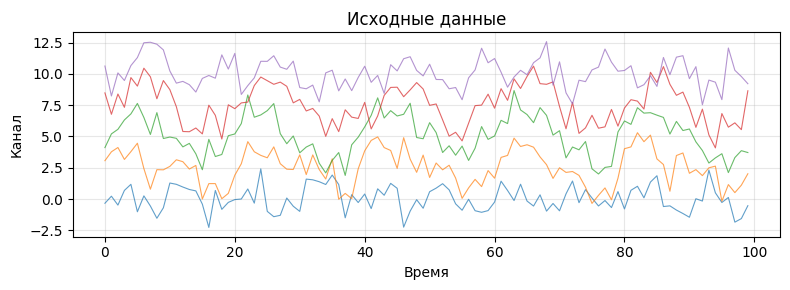

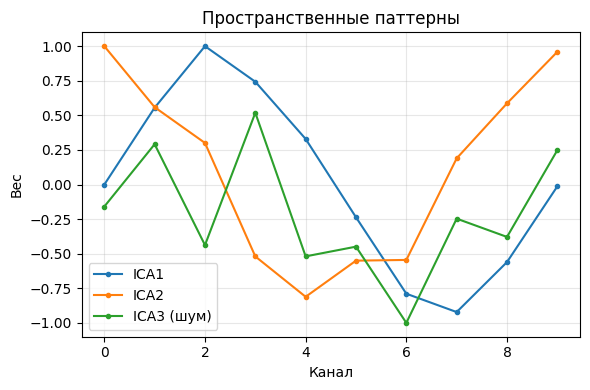

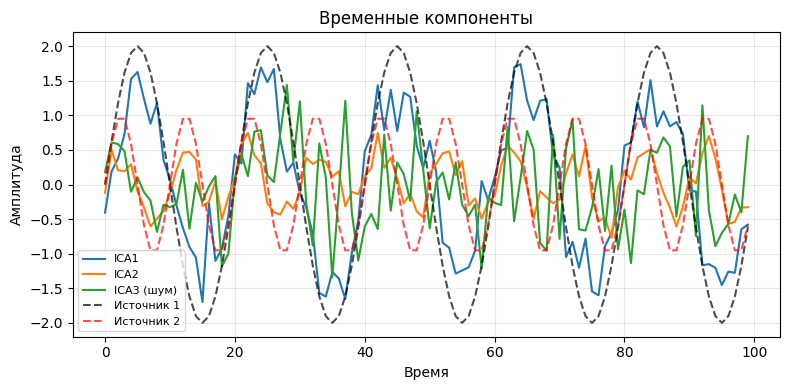

ICA: corr1 = 0.9531, corr2 = 0.8680


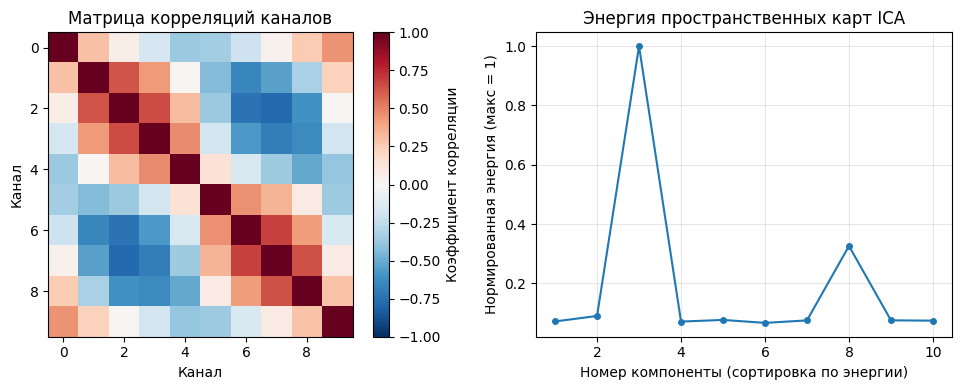

In [4]:
# ======================== ЗАДАНИЕ 3: ICA ========================
print("\n=== ЗАДАНИЕ 3: ICA ===")
X_ica_input = noisy_2 - noisy_2.mean(axis=1, keepdims=True)

# <-- Подготовка: X_ica = X_ica_input.T (время, каналы)
X_ica = X_ica_input.T

# <-- FastICA с n_components=N_CHANNELS, random_state=42, whiten='arbitrary-variance'
ica = FastICA(n_components=N_CHANNELS, random_state=42, whiten='arbitrary-variance')
sources = ica.fit_transform(X_ica)  # результат fit_transform (время, компоненты)
mixing = ica.mixing_  # ica.mixing_

# <-- Преобразуйте sources.T -> (компоненты, время), spatial_maps = mixing.T
sources = sources.T
spatial_maps = mixing.T

# <-- Сортировка по энергии spatial_maps (сумма квадратов по каналам)
energy = np.sum(spatial_maps**2, axis=1)
sorted_idx = np.argsort(energy)[::-1]
spatial_maps = spatial_maps[sorted_idx]
sources = sources[sorted_idx]

# <-- Найдите индексы компонент, максимально коррелирующих с temporal_1 и temporal_2 (независимо)
corrs_with_1 = [abs(np.corrcoef(s, temporal_1)[0, 1]) for s in sources]
corrs_with_2 = [abs(np.corrcoef(s, temporal_2)[0, 1]) for s in sources]

idx1 = np.argmax(corrs_with_1)
idx2 = np.argmax(corrs_with_2)

# Защита на случай, если одна и та же компонента сработала на оба источника
if idx1 == idx2:
    corrs_with_2[idx1] = 0
    idx2 = np.argmax(corrs_with_2)

noise_idx = [i for i in range(N_CHANNELS) if i not in (idx1, idx2)][0]

# ПРАВИЛЬНАЯ распаковка: w (пространство), t (время)
w1i, t1i = normalize_component(spatial_maps[idx1], sources[idx1], temporal_1, AMP_1)
w2i, t2i = normalize_component(spatial_maps[idx2], sources[idx2], temporal_2, AMP_2)
w3i, t3i = normalize_component(spatial_maps[noise_idx], sources[noise_idx])

# Отрисовка нормализованных данных
plot_results(noisy_2, [t1i, t2i, t3i], 
             [w1i, w2i, w3i], [f'ICA{idx1+1}', f'ICA{idx2+1}', f'ICA{noise_idx+1} (шум)'])

# <-- Корреляции
corr1_ica = np.corrcoef(t1i, temporal_1)[0, 1]
corr2_ica = np.corrcoef(t2i, temporal_2)[0, 1]
print(f"ICA: corr1 = {corr1_ica:.4f}, corr2 = {corr2_ica:.4f}")


# --- ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ ДЛЯ ICA ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. Матрица корреляций (данные те же, что и во 2 задании)
im = axes[0].imshow(np.corrcoef(noisy_2), cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Матрица корреляций каналов')
axes[0].set_xlabel('Канал'); axes[0].set_ylabel('Канал')
plt.colorbar(im, ax=axes[0], label='Коэффициент корреляции')

# 2. Энергия пространственных карт
axes[1].plot(range(1, len(energy) + 1), energy / np.max(energy), marker='o', ms=4)
axes[1].set_title('Энергия пространственных карт ICA')
axes[1].set_xlabel('Номер компоненты (сортировка по энергии)')
axes[1].set_ylabel('Нормированная энергия (макс = 1)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()